In [56]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [57]:
from google.colab import files

uploaded = files.upload()

for fn in uploaded.keys():
  print(f'Uploaded CO2_Emissions.csv "{fn}" with length {len(uploaded[fn])} bytes')


Saving CO2_Emissions.csv to CO2_Emissions (3).csv
Uploaded CO2_Emissions.csv "CO2_Emissions (3).csv" with length 476091 bytes


# Question 1

Begin by familiarizing yourself with the dataset. Identify what kind of information is captured about vehicles and how these variables might influence CO₂ emissions.

In [58]:
# Load dataset
df = pd.read_csv("CO2_Emissions.csv")

print("Dataset shape:", df.shape)
print("\nColumn info:")
print(df.info())
print("\nFirst few rows:")
print(df.head())

Dataset shape: (7385, 12)

Column info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7385 entries, 0 to 7384
Data columns (total 12 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   Make                              7385 non-null   object 
 1   Model                             7385 non-null   object 
 2   Vehicle Class                     7385 non-null   object 
 3   Engine Size(L)                    7385 non-null   float64
 4   Cylinders                         7385 non-null   int64  
 5   Transmission                      7385 non-null   object 
 6   Fuel Type                         7385 non-null   object 
 7   Fuel Consumption City (L/100 km)  7385 non-null   float64
 8   Fuel Consumption Hwy (L/100 km)   7385 non-null   float64
 9   Fuel Consumption Comb (L/100 km)  7385 non-null   float64
 10  Fuel Consumption Comb (mpg)       7385 non-null   int64  
 11  CO2 Emissions(g/km)          

# Question 2

Examine the dataset for any inconsistencies, missing entries, or data quality issues. Consider what preprocessing steps may be necessary to make the dataset ready for meaningful analysis.

In [59]:

#  Missing Values
print("\nMissing values per column:")
print(df.isnull().sum())


Missing values per column:
Make                                0
Model                               0
Vehicle Class                       0
Engine Size(L)                      0
Cylinders                           0
Transmission                        0
Fuel Type                           0
Fuel Consumption City (L/100 km)    0
Fuel Consumption Hwy (L/100 km)     0
Fuel Consumption Comb (L/100 km)    0
Fuel Consumption Comb (mpg)         0
CO2 Emissions(g/km)                 0
dtype: int64


In [60]:
# Duplicate Records
duplicates = df.duplicated().sum()
print(f"\nNumber of duplicate rows: {duplicates}")


Number of duplicate rows: 1103


In [61]:
#remove duplicate
print("Before removing duplicates:", df.shape)
df = df.drop_duplicates()
print("After removing duplicates:", df.shape)

Before removing duplicates: (7385, 12)
After removing duplicates: (6282, 12)


In [62]:
# remove inconsistent Categorical Values
categorical_cols = df.select_dtypes(include=['object']).columns
for col in categorical_cols:
    print(f"\nUnique values in {col}:")
    print(df[col].unique())


Unique values in Make:
['ACURA' 'ALFA ROMEO' 'ASTON MARTIN' 'AUDI' 'BENTLEY' 'BMW' 'BUICK'
 'CADILLAC' 'CHEVROLET' 'CHRYSLER' 'DODGE' 'FIAT' 'FORD' 'GMC' 'HONDA'
 'HYUNDAI' 'INFINITI' 'JAGUAR' 'JEEP' 'KIA' 'LAMBORGHINI' 'LAND ROVER'
 'LEXUS' 'LINCOLN' 'MASERATI' 'MAZDA' 'MERCEDES-BENZ' 'MINI' 'MITSUBISHI'
 'NISSAN' 'PORSCHE' 'RAM' 'ROLLS-ROYCE' 'SCION' 'SMART' 'SRT' 'SUBARU'
 'TOYOTA' 'VOLKSWAGEN' 'VOLVO' 'GENESIS' 'BUGATTI']

Unique values in Model:
['ILX' 'ILX HYBRID' 'MDX 4WD' ... 'Tacoma 4WD D-Cab TRD Off-Road/Pro'
 'Atlas Cross Sport 4MOTION' 'XC40 T4 AWD']

Unique values in Vehicle Class:
['COMPACT' 'SUV - SMALL' 'MID-SIZE' 'TWO-SEATER' 'MINICOMPACT'
 'SUBCOMPACT' 'FULL-SIZE' 'STATION WAGON - SMALL' 'SUV - STANDARD'
 'VAN - CARGO' 'VAN - PASSENGER' 'PICKUP TRUCK - STANDARD' 'MINIVAN'
 'SPECIAL PURPOSE VEHICLE' 'STATION WAGON - MID-SIZE'
 'PICKUP TRUCK - SMALL']

Unique values in Transmission:
['AS5' 'M6' 'AV7' 'AS6' 'AM6' 'A6' 'AM7' 'AV8' 'AS8' 'A7' 'A8' 'M7' 'A4'
 'M5' 'AV' 'A5

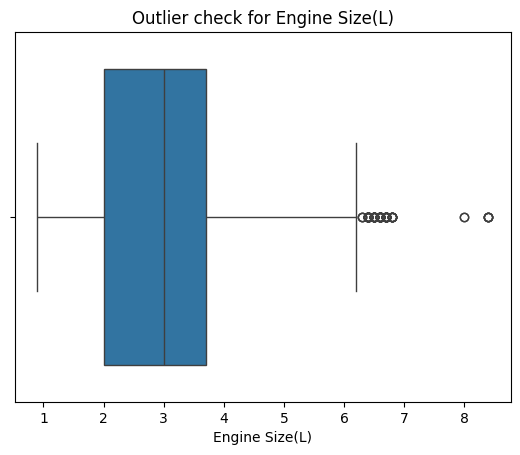

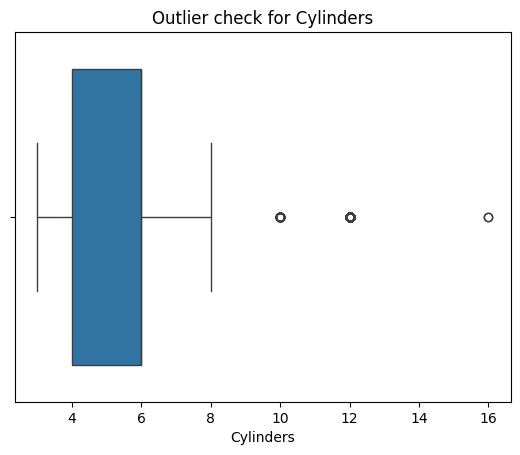

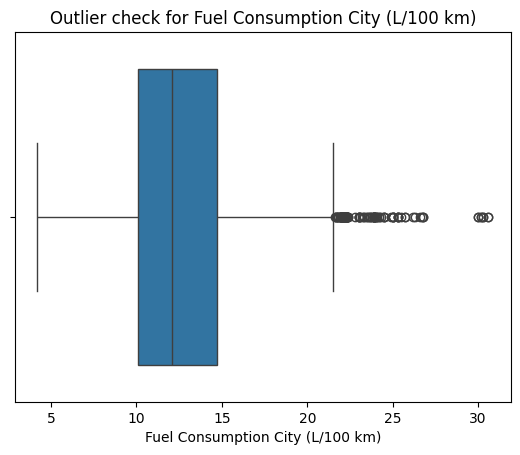

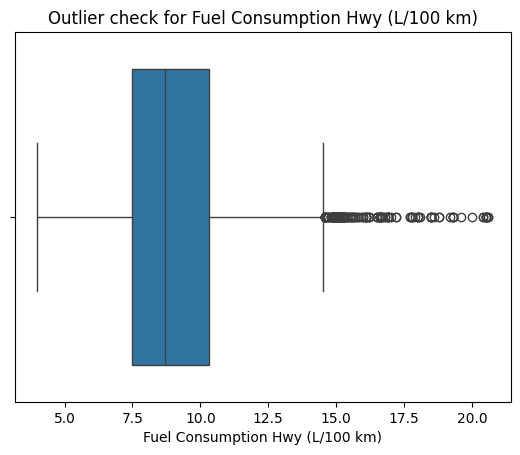

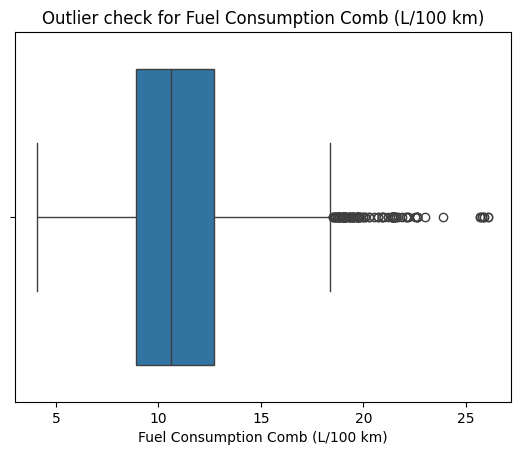

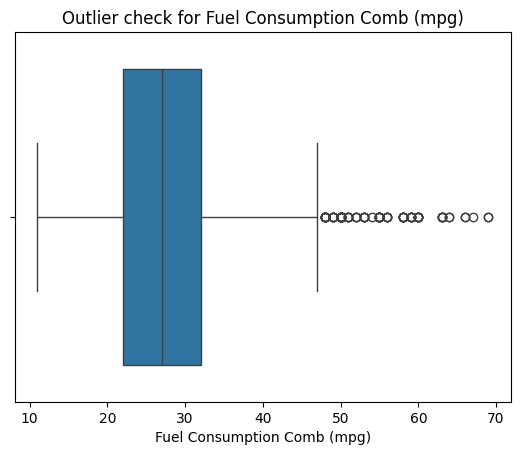

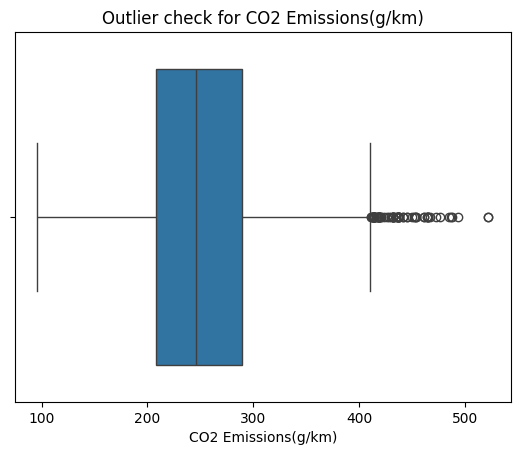

In [63]:
#Outlier Detection

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outlier check for {col}")
    plt.show()


In [64]:

# Range & Unit Consistency checks (adjust based on dataset columns)
if 'CO2_Emissions' in df.columns:
    print("\nCO2 Emissions range:", df['CO2_Emissions'].min(), "-", df['CO2_Emissions'].max())

if 'Engine_Size' in df.columns:
    print("\nEngine Size range:", df['Engine_Size'].min(), "-", df['Engine_Size'].max())

# Saving Cleaned Dataset

df.to_csv("CO2_Emissions_Cleaned.csv", index=False)
print("\nCleaned dataset saved as CO2_Emissions_Cleaned.csv")


Cleaned dataset saved as CO2_Emissions_Cleaned.csv


In [65]:
print(f"DataFrame shape before outlier removal: {df.shape}")

# Identify numeric columns again, as the previous one might be in an old state
numeric_cols = df.select_dtypes(include=[np.number]).columns

# Loop through each numeric column to remove outliers using IQR
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    # Filter out outliers for the current column
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]

print(f"DataFrame shape after outlier removal: {df.shape}")


DataFrame shape before outlier removal: (6282, 12)
DataFrame shape after outlier removal: (5670, 12)


Re-plotting boxplots after outlier removal:


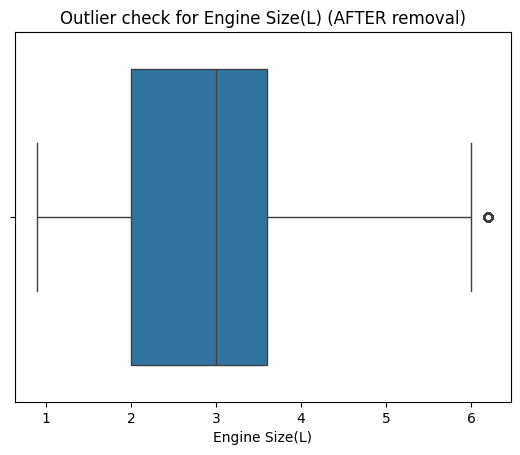

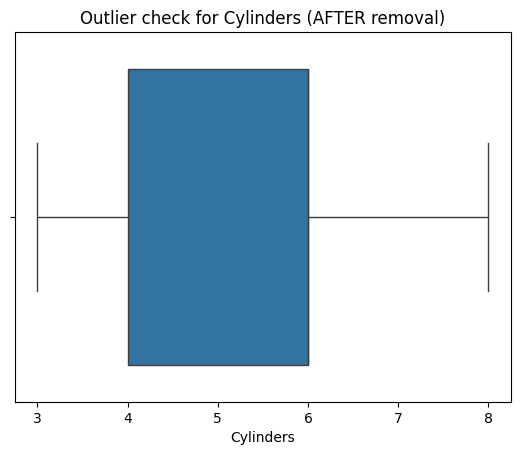

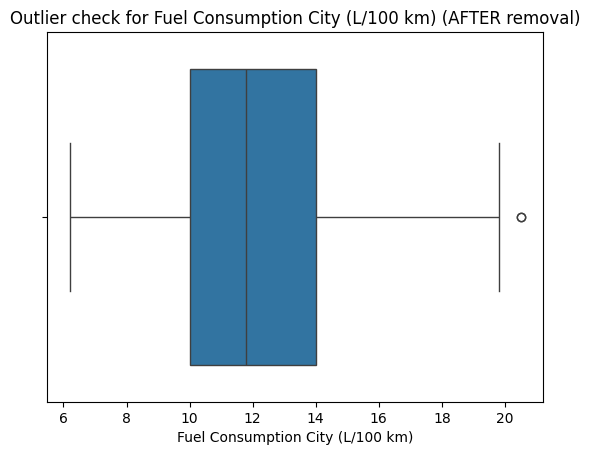

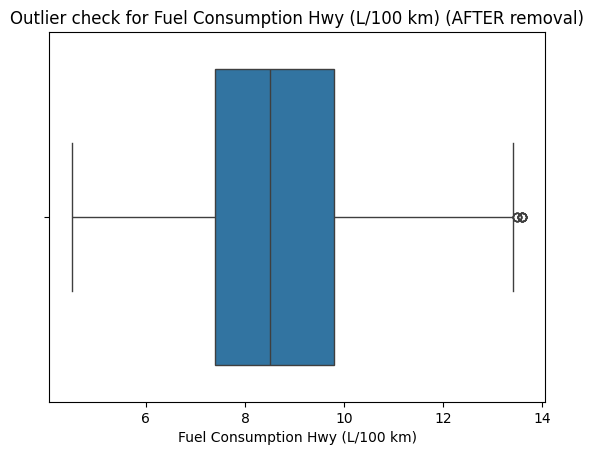

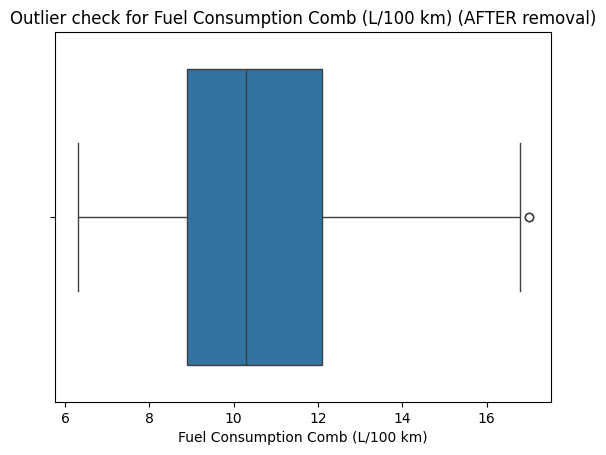

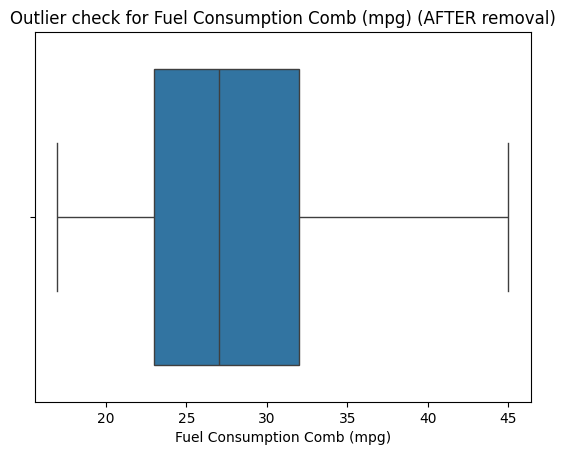

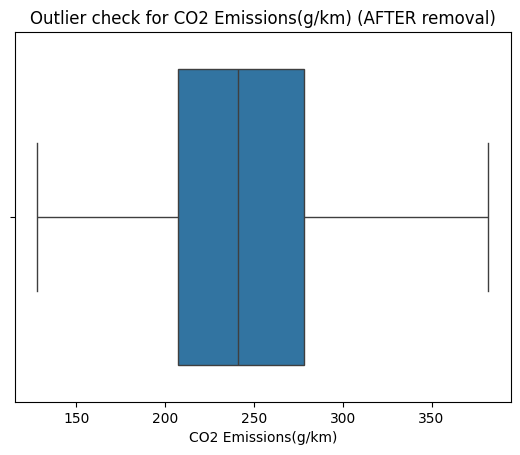

In [66]:
# -------------------------------# Re-plotting Boxplots AFTER Outlier Removal# -------------------------------import numpy as np

print("Re-plotting boxplots after outlier removal:")

numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    plt.figure()
    sns.boxplot(x=df[col])
    plt.title(f"Outlier check for {col} (AFTER removal)")
    plt.show()

The code above has removed outliers based on the IQR method for all numeric columns. You can see the change in the DataFrame's shape before and after the removal.

# Question 3:

Study the relationships between various vehicle features and CO₂ emissions. Which attributes appear to have stronger influence on emission levels? Use suitable methods to support your reasoning.

 Step 1: Correlation Analysis
- Compute Pearson correlation coefficients between numeric features (engine size, fuel consumption, vehicle weight, horsepower) and CO₂ emissions.
- Strong positive correlations usually appear with:
- Engine size/displacement -> larger engines burn more fuel.
- Fuel consumption (L/100km or mpg) -> directly tied to emissions.
- Vehicle weight -> heavier vehicles require more energy.


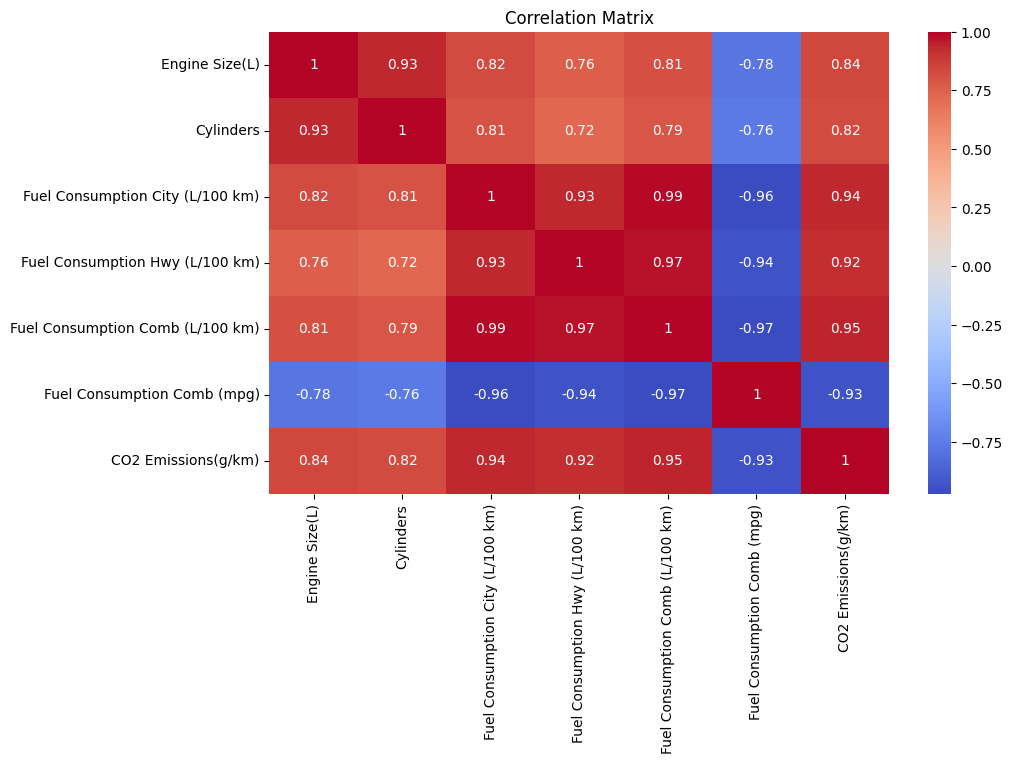

In [67]:

# Select only numeric columns for correlation calculation
numeric_cols = df.select_dtypes(include=[np.number]).columns
corr = df[numeric_cols].corr()

plt.figure(figsize=(10,6))
sns.heatmap(corr, annot=True, cmap="coolwarm")
plt.title("Correlation Matrix")
plt.show()

Group Comparisons
- Compare average CO₂ emissions across categories:
- Fuel type (diesel vs petrol vs hybrid vs electric).
- Transmission type (manual vs automatic).
- Vehicle class (SUV vs sedan vs compact).


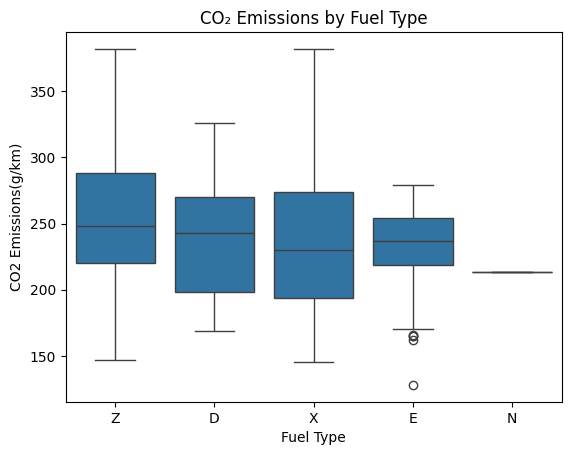

In [68]:
sns.boxplot(x="Fuel Type", y="CO2 Emissions(g/km)", data=df)
plt.title("CO₂ Emissions by Fuel Type")
plt.show()

In [69]:
# Reload the cleaned dataset to ensure correct state after duplicate removal
df = pd.read_csv("CO2_Emissions_Cleaned.csv")

# Re-apply outlier removal (as CO2_Emissions_Cleaned.csv was saved before this step)
print(f"DataFrame shape before outlier removal: {df.shape}")
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    df = df[(df[col] >= lower_bound) & (df[col] <= upper_bound)]
print(f"DataFrame shape after outlier removal: {df.shape}")

# Perform one-hot encoding for categorical variables
categorical_cols = ['Make', 'Vehicle Class', 'Transmission', 'Fuel Type']
# Preserve the DataFrame with original categorical columns for plotting
df_original_categorical = df.copy()
df_encoded = pd.get_dummies(df, columns=categorical_cols, drop_first=True)

print("DataFrame shape after one-hot encoding:", df_encoded.shape)
print("First few rows of encoded DataFrame:")
display(df_encoded.head())

DataFrame shape before outlier removal: (6282, 12)
DataFrame shape after outlier removal: (5670, 12)
DataFrame shape after one-hot encoding: (5670, 90)
First few rows of encoded DataFrame:


,Model,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg),CO2 Emissions(g/km),Make_ALFA ROMEO,Make_ASTON MARTIN,...,Transmission_AV6,Transmission_AV7,Transmission_AV8,Transmission_M5,Transmission_M6,Transmission_M7,Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z
0,ILX,2.0,4,9.9,6.7,8.5,33,196,False,False,...,False,False,False,False,False,False,False,False,False,True
1,ILX,2.4,4,11.2,7.7,9.6,29,221,False,False,...,False,False,False,False,True,False,False,False,False,True
3,MDX 4WD,3.5,6,12.7,9.1,11.1,25,255,False,False,...,False,False,False,False,False,False,False,False,False,True
4,RDX AWD,3.5,6,12.1,8.7,10.6,27,244,False,False,...,False,False,False,False,False,False,False,False,False,True
5,RLX,3.5,6,11.9,7.7,10.0,28,230,False,False,...,False,False,False,False,False,False,False,False,False,True


Top 10 Regression Coefficients (by absolute value):
Fuel Type_E: -129.56
Fuel Type_N: -112.53
Fuel Type_X: -31.38
Fuel Type_Z: -31.35
Fuel Consumption Comb (L/100 km): 10.24
Fuel Consumption City (L/100 km): 5.73
Fuel Consumption Hwy (L/100 km): 5.59
Transmission_AS4: -4.24
Make_GENESIS: 4.15
Make_BENTLEY: 3.94

Intercept: 66.94509706983294
R² score (Linear Regression): 0.9957875427731795


/tmp/ipykernel_305/3919997485.py:50: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


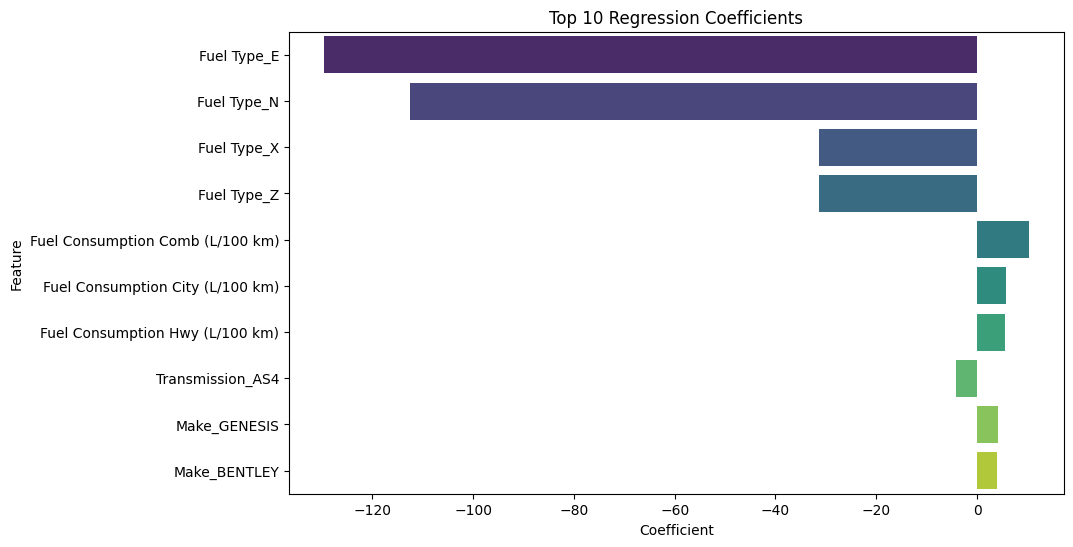


Top 10 Random Forest Feature Importances:
Fuel Consumption Comb (L/100 km): 0.689
Fuel Consumption Comb (mpg): 0.247
Fuel Type_E: 0.051
Fuel Consumption City (L/100 km): 0.002
Vehicle Class_PICKUP TRUCK - STANDARD: 0.002
Vehicle Class_PICKUP TRUCK - SMALL: 0.001
Vehicle Class_SUV - STANDARD: 0.001
Fuel Consumption Hwy (L/100 km): 0.001
Fuel Type_X: 0.001
Engine Size(L): 0.001


/tmp/ipykernel_305/3919997485.py:70: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=imp_df, palette='magma')


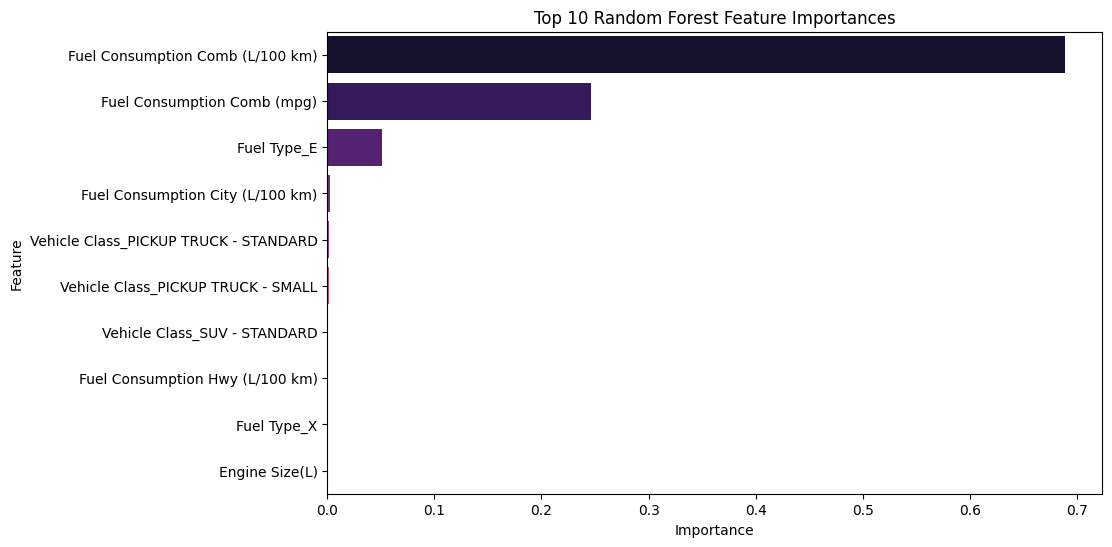

In [70]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score
from sklearn.ensemble import RandomForestRegressor

# Use the one-hot encoded DataFrame
df = df_encoded

# Numeric predictors
numeric_predictors = ['Engine Size(L)', 'Cylinders',
                      'Fuel Consumption City (L/100 km)',
                      'Fuel Consumption Hwy (L/100 km)',
                      'Fuel Consumption Comb (L/100 km)',
                      'Fuel Consumption Comb (mpg)']

# One-hot encoded categorical predictors
one_hot_encoded_cols = [col for col in df.columns
                        if col.startswith(('Make_', 'Vehicle Class_', 'Transmission_', 'Fuel Type_'))]

# Combine predictors
predictors = numeric_predictors + one_hot_encoded_cols

# Features and target
X = df[predictors]
y = df['CO2 Emissions(g/km)']

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


# --------------------------------------------Linear Regression--------------------------------------------

lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

coefficients = dict(zip(predictors, lin_model.coef_))

print("Top 10 Regression Coefficients (by absolute value):")
for feature, coef in sorted(coefficients.items(), key=lambda item: abs(item[1]), reverse=True)[:10]:
    print(f"{feature}: {coef:.2f}")

print("\nIntercept:", lin_model.intercept_)
print("R² score (Linear Regression):", r2_score(y_test, lin_model.predict(X_test)))

# Plot coefficients
top_coef = sorted(coefficients.items(), key=lambda item: abs(item[1]), reverse=True)[:10]
coef_df = pd.DataFrame(top_coef, columns=['Feature','Coefficient'])

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title("Top 10 Regression Coefficients")
plt.show()

# ----------------------------------------------Random Forest-----------------------------------------------

rf_model = RandomForestRegressor(n_estimators=200, random_state=42)
rf_model.fit(X_train, y_train)

importances = dict(zip(predictors, rf_model.feature_importances_))

print("\nTop 10 Random Forest Feature Importances:")
for feature, score in sorted(importances.items(), key=lambda item: item[1], reverse=True)[:10]:
    print(f"{feature}: {score:.3f}")

# Plot feature importance
top_importances = sorted(importances.items(), key=lambda item: item[1], reverse=True)[:10]
imp_df = pd.DataFrame(top_importances, columns=['Feature','Importance'])

plt.figure(figsize=(10,6))
sns.barplot(x='Importance', y='Feature', data=imp_df, palette='magma')
plt.title("Top 10 Random Forest Feature Importances")
plt.show()

Key Influencers of Vehicle CO₂ Emissions
The analysis using both multiple linear regression and Random Forest feature importance consistently highlights that fuel consumption and fuel type are the strongest determinants of vehicle CO₂ emissions.
- Fuel consumption (combined, city, highway) emerged as the most influential predictor. Regression coefficients show a clear positive relationship, with each unit increase in fuel consumption leading to higher emissions. Random Forest importance scores confirm this dominance, ranking combined fuel consumption far above other variables.
- Fuel type plays a critical categorical role. Regression coefficients for certain fuel types (e.g., hybrids or electrics) are strongly negative, indicating significantly lower emissions compared to conventional fuels. Random Forest also ranks fuel type among the top predictors, reinforcing its importance.
- Engine size and cylinders contribute positively to emissions, though their influence is secondary compared to fuel consumption.
- Vehicle class (e.g., pickup trucks, vans) shows moderate influence, reflecting structural and weight differences across categories.
Together, these findings demonstrate that fuel consumption metrics and fuel type are the primary drivers of CO₂ emissions, while engine size and vehicle class exert secondary but consistent effects. Regression analysis provides interpretable effect sizes, while Random Forest validates these results by ranking predictors according to their contribution to predictive accuracy. Using both methods offers a robust and comprehensive understanding of emission drivers, supporting data‑driven policy and design decisions in the automotive sector.


# Question 4:

Create visual summaries that reveal how emission levels change with respect to different numerical variables in the dataset. Focus on uncovering patterns or trends that might not be immediately visible.

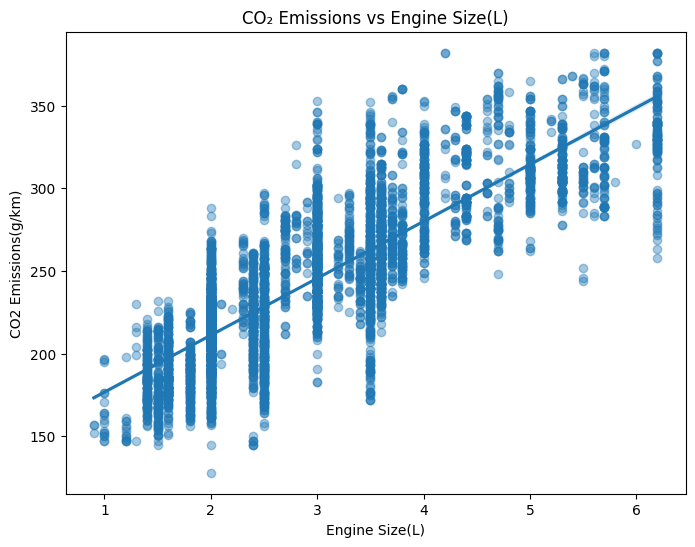

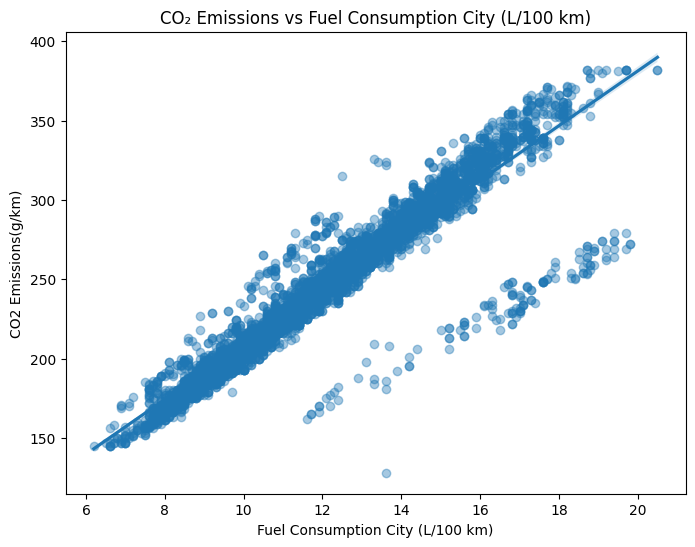

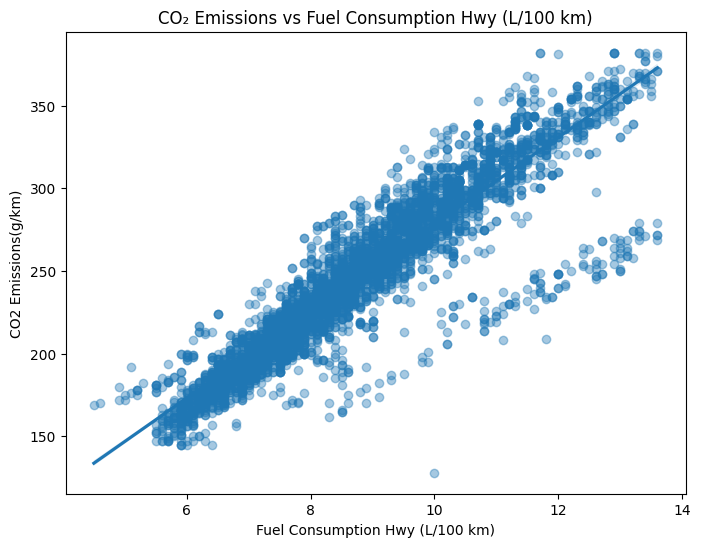

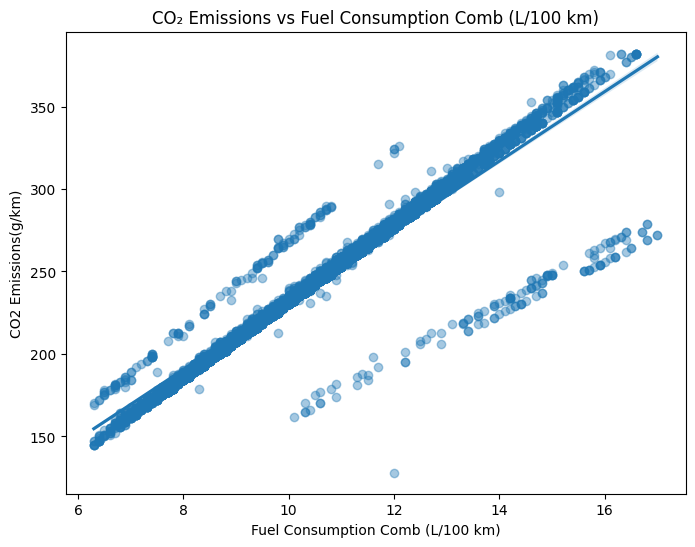

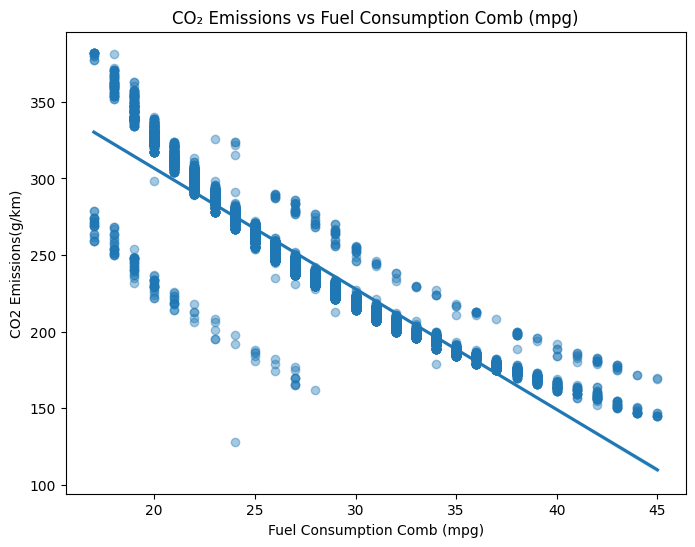

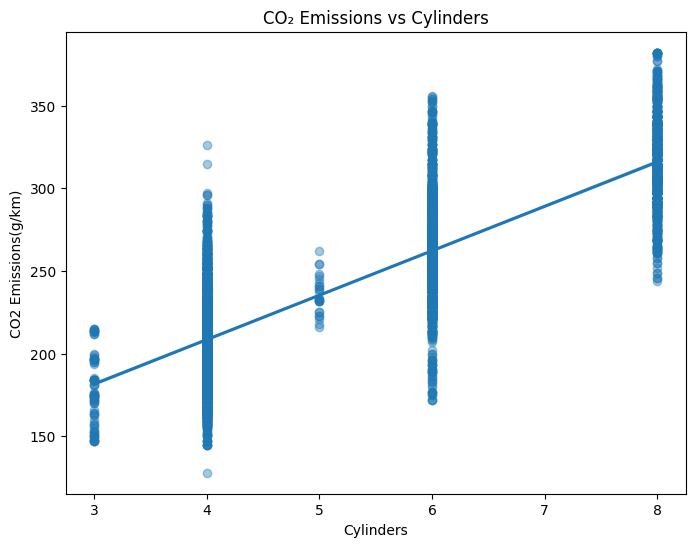

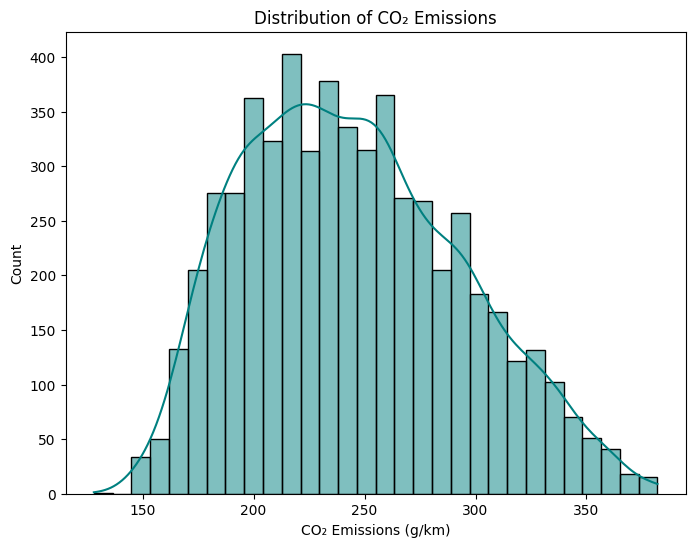

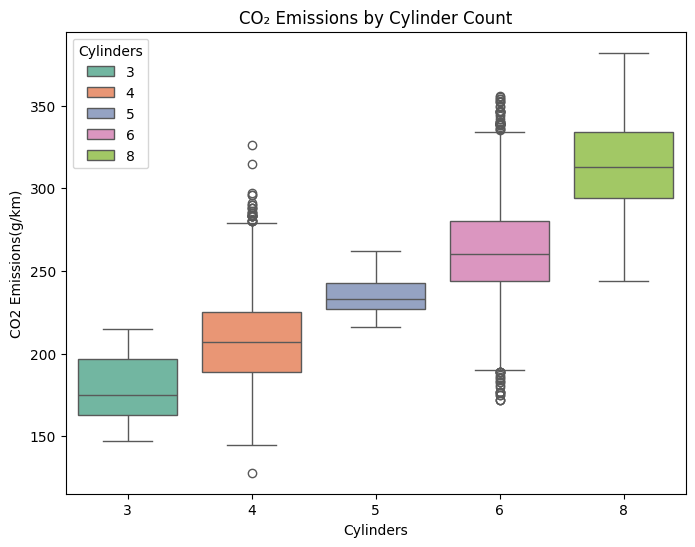

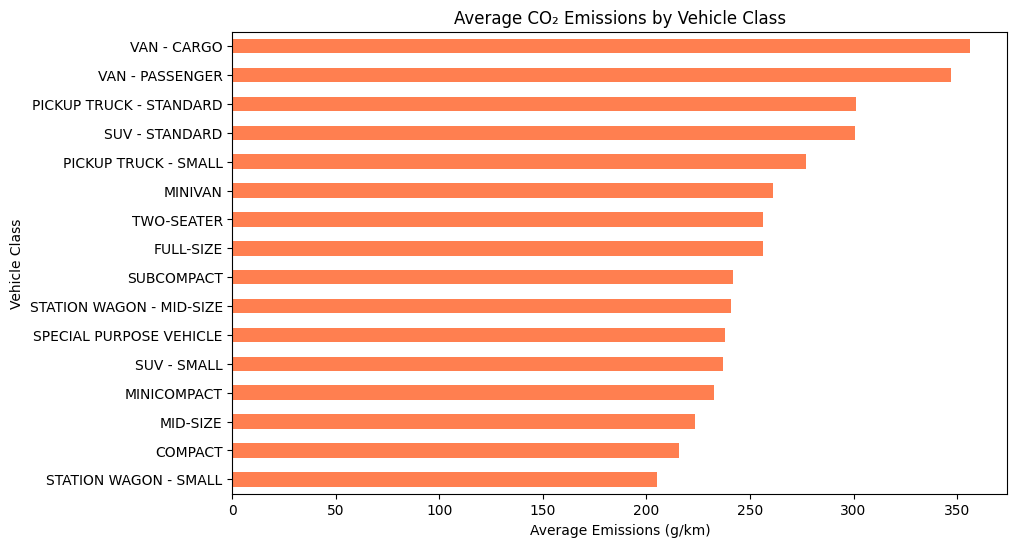

In [71]:
df_for_plots = df_encoded # Renamed to avoid confusion with original df


# Scatter plots with trend lines
numeric_vars = [
    "Engine Size(L)",
    "Fuel Consumption City (L/100 km)",
    "Fuel Consumption Hwy (L/100 km)",
    "Fuel Consumption Comb (L/100 km)",
    "Fuel Consumption Comb (mpg)",
    "Cylinders"
]

for var in numeric_vars:
    plt.figure(figsize=(8,6))
    sns.regplot(x=var, y="CO2 Emissions(g/km)", data=df_for_plots, scatter_kws={'alpha':0.4})
    plt.title(f"CO₂ Emissions vs {var}")
    plt.show()

# Distribution of CO₂ emissions
plt.figure(figsize=(8,6))
sns.histplot(df_for_plots["CO2 Emissions(g/km)"], bins=30, kde=True, color="teal")
plt.title("Distribution of CO₂ Emissions")
plt.xlabel("CO₂ Emissions (g/km)")
plt.ylabel("Count")
plt.show()

# Boxplots by Cylinders
plt.figure(figsize=(8,6))
sns.boxplot(x="Cylinders", y="CO2 Emissions(g/km)", data=df_for_plots, palette="Set2", hue=df['Cylinders'])
plt.title("CO₂ Emissions by Cylinder Count")
plt.show()


# Average emissions by vehicle class
plt.figure(figsize=(10,6))
# Use df_original_categorical for this plot as it retains the 'Vehicle Class' column
df_original_categorical.groupby("Vehicle Class")["CO2 Emissions(g/km)"].mean().sort_values().plot(kind="barh", color="coral")
plt.title("Average CO₂ Emissions by Vehicle Class")
plt.xlabel("Average Emissions (g/km)")
plt.show()

# Question 5:

Compare emission levels across different vehicle types or fuel categories. Identify any clear distinctions or surprising findings that emerge.

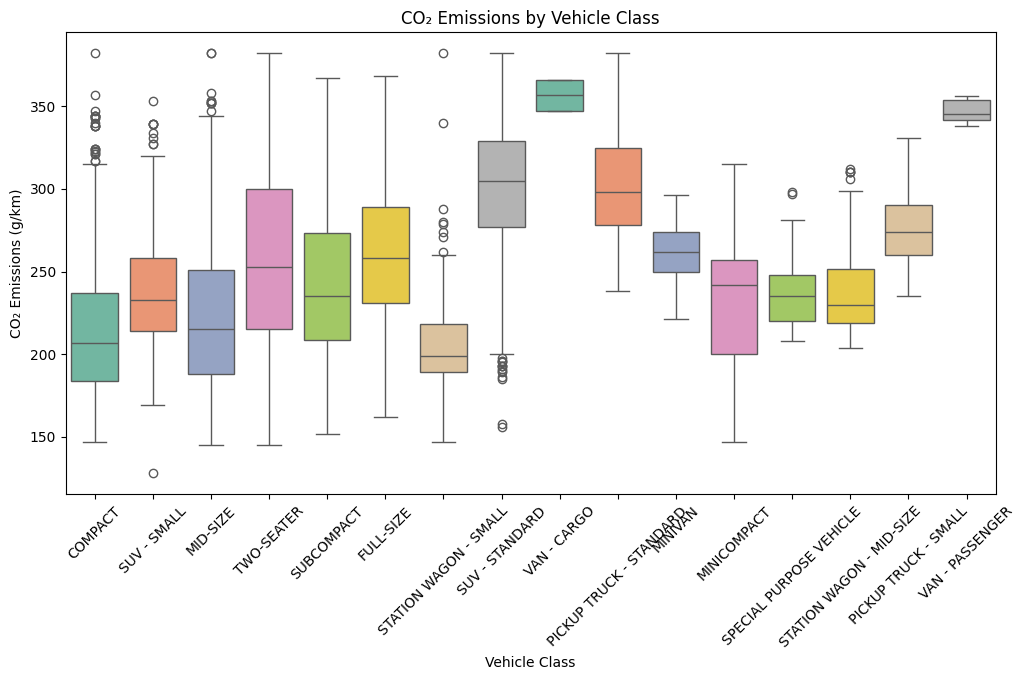

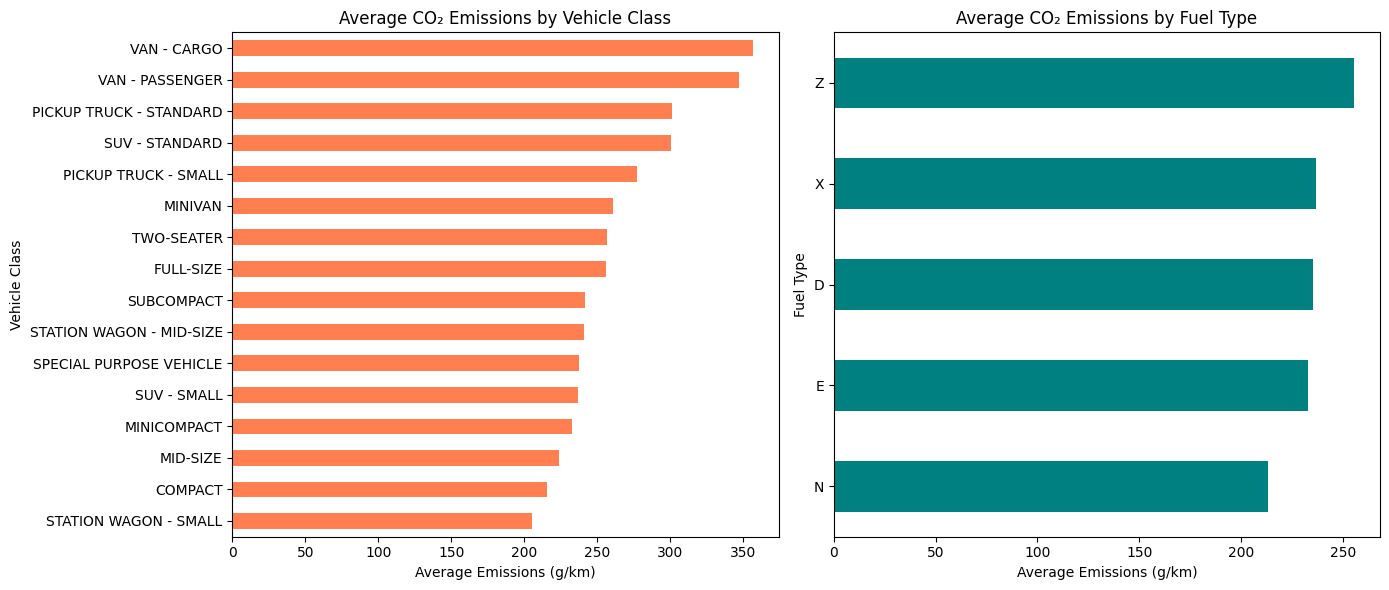

In [72]:
# Boxplot: CO₂ Emissions by Vehicle Class
plt.figure(figsize=(12,6))
sns.boxplot(x="Vehicle Class", y="CO2 Emissions(g/km)", data=df_original_categorical, palette="Set2", hue="Vehicle Class")
plt.xlabel("Vehicle Class")
plt.ylabel("CO₂ Emissions (g/km)")
plt.xticks(rotation=45)
plt.title("CO₂ Emissions by Vehicle Class")
plt.show()

# Average Emissions Comparison (Bar Charts)
fig, axes = plt.subplots(1, 2, figsize=(14,6))

# Vehicle Class averages
df_original_categorical.groupby("Vehicle Class")["CO2 Emissions(g/km)"].mean().sort_values().plot(
    kind="barh", ax=axes[0], color="coral")
axes[0].set_title("Average CO₂ Emissions by Vehicle Class")
axes[0].set_xlabel("Average Emissions (g/km)")

# Fuel Type averages
df_original_categorical.groupby("Fuel Type")["CO2 Emissions(g/km)"].mean().sort_values().plot(
    kind="barh", ax=axes[1], color="teal")
axes[1].set_title("Average CO₂ Emissions by Fuel Type")
axes[1].set_xlabel("Average Emissions (g/km)")

plt.tight_layout()
plt.show()

# Question 6

Observe if there are any vehicles that produce unusually high or low emissions compared to others with similar characteristics. Reflect on what could explain such deviations.

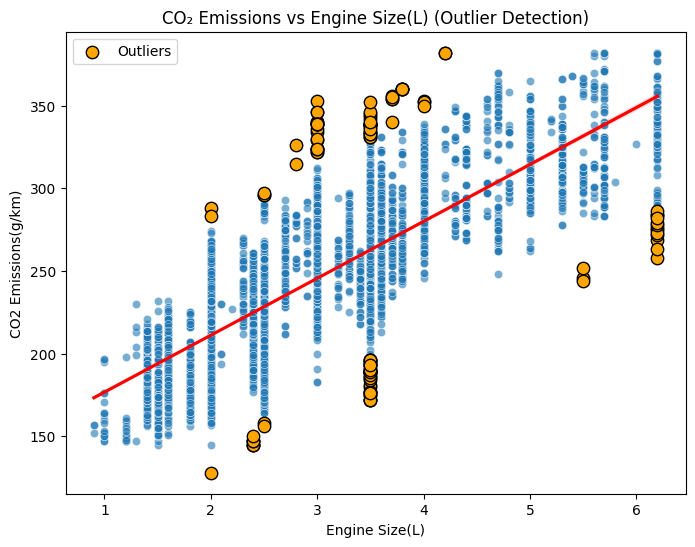


Outliers for Engine Size(L):
     Engine Size(L)  CO2 Emissions(g/km)        Make                  Model  \
195             6.2                  276   CHEVROLET               CORVETTE   
196             6.2                  258   CHEVROLET               CORVETTE   
516             2.4                  145     HYUNDAI  SONATA HYBRID LIMITED   
528             3.5                  172    INFINITI             Q50 HYBRID   
529             3.5                  189    INFINITI         Q50 HYBRID AWD   
539             3.5                  175    INFINITI             Q70 HYBRID   
618             2.4                  147         KIA       OPTIMA HYBRID EX   
641             3.0                  334  LAND ROVER                    LR4   
664             3.5                  175       LEXUS                GS 450h   
680             3.5                  189       LEXUS            RX 450h AWD   

    Fuel Type   Vehicle Class  
195         Z      TWO-SEATER  
196         Z      TWO-SEATER  
516 

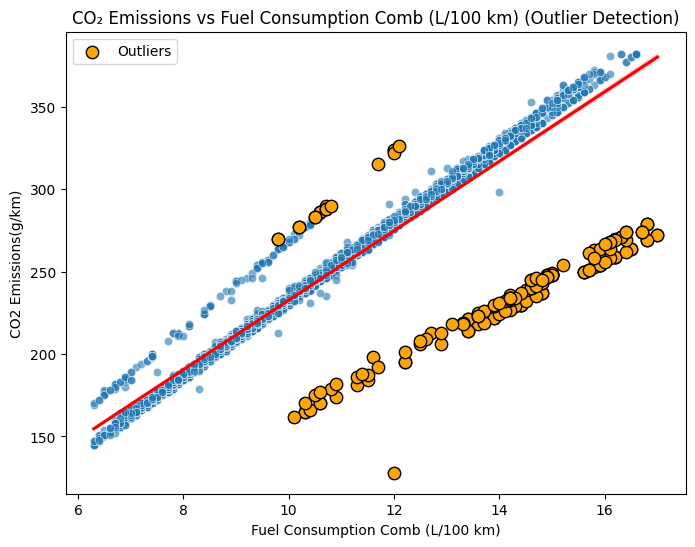


Outliers for Fuel Consumption Comb (L/100 km):
     Fuel Consumption Comb (L/100 km)  CO2 Emissions(g/km)       Make  \
44                               10.7                  290       AUDI   
145                              15.6                  250      BUICK   
147                              16.5                  264      BUICK   
206                              16.2                  259  CHEVROLET   
209                              17.0                  272  CHEVROLET   
231                              14.3                  229  CHEVROLET   
278                              14.4                  230   CHRYSLER   
282                              14.4                  230   CHRYSLER   
287                              14.8                  237   CHRYSLER   
289                              13.9                  222   CHRYSLER   

                   Model Fuel Type   Vehicle Class  
44     Q7 TDI (modified)         D  SUV - STANDARD  
145             LACROSSE         E        

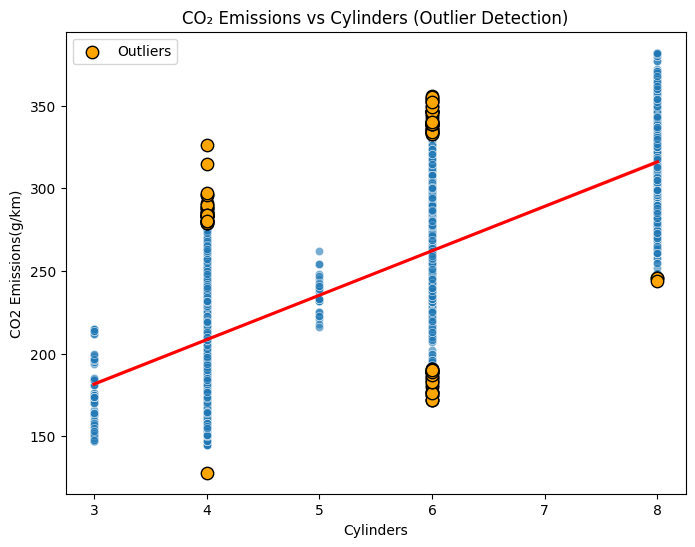


Outliers for Cylinders:
     Cylinders  CO2 Emissions(g/km)           Make               Model  \
113          6                  191            BMW      ACTIVEHYBRID 3   
210          6                  347      CHEVROLET  EXPRESS 1500 CARGO   
434          6                  347            GMC   SAVANA 1500 CARGO   
528          6                  172       INFINITI          Q50 HYBRID   
529          6                  189       INFINITI      Q50 HYBRID AWD   
539          6                  175       INFINITI          Q70 HYBRID   
641          6                  334     LAND ROVER                 LR4   
664          6                  175          LEXUS             GS 450h   
680          6                  189          LEXUS         RX 450h AWD   
780          8                  246  MERCEDES-BENZ          SLK 55 AMG   

    Fuel Type   Vehicle Class  
113         Z         COMPACT  
210         X     VAN - CARGO  
434         X     VAN - CARGO  
528         Z         COMPACT  


In [73]:
# Define target and key predictors
target = "CO2 Emissions(g/km)"
predictors = ["Engine Size(L)",
              "Fuel Consumption Comb (L/100 km)",
              "Cylinders"]

# Function to plot scatter + regression + highlight outliers
def plot_outliers(df, x_var, y_var=target, threshold=2.5):
    plt.figure(figsize=(8,6))

    # Scatter plot
    sns.scatterplot(x=x_var, y=y_var, data=df, alpha=0.6)

    # Regression line
    sns.regplot(x=x_var, y=y_var, data=df, scatter=False, color="red")

    # Fit regression line manually to compute residuals
    coeffs = np.polyfit(df[x_var], df[y_var], 1)
    predicted = np.polyval(coeffs, df[x_var])
    residuals = df[y_var] - predicted

    # Identify outliers (vehicles far above/below trend line)
    outliers = df[np.abs(residuals) > threshold * np.std(residuals)]

    # Highlight outliers
    plt.scatter(outliers[x_var], outliers[y_var],
                color="orange", edgecolor="black", s=80, label="Outliers")

    plt.title(f"CO₂ Emissions vs {x_var} (Outlier Detection)")
    plt.legend()
    plt.show()

    # Print outlier details
    print(f"\nOutliers for {x_var}:")
    print(outliers[[x_var, y_var, "Make", "Model", "Fuel Type", "Vehicle Class"]].head(10))

# Run for key predictors
for var in predictors:
    plot_outliers(df_original_categorical, var)

Vehicles with Unusually Low Emissions (Efficiency-Driven Outliers):

- Hybrid Models: Several hybrid vehicles (e.g., Hyundai Sonata Hybrid, Infiniti Q50 Hybrid, Lexus GS 450h) consistently appear as outliers with lower CO₂ emissions than expected for their engine size. This is a clear reflection of hybrid technology, which combines a gasoline engine with an electric motor, leading to improved fuel efficiency and reduced emissions, especially in city driving.
- Alternative Fuel Vehicles (Ethanol/Natural Gas): Vehicles using 'E' (Ethanol) and 'N' (Natural Gas) fuel types often exhibit lower CO₂ emissions for their measured fuel consumption. For ethanol, this could be due to its combustion properties or the regulatory framework for flex-fuel vehicles. Natural gas vehicles inherently produce less CO₂ per unit of energy compared to gasoline.


Vehicles with Unusually High Emissions (Performance/Segment-Driven Outliers):

- Performance Vehicles: High-performance vehicles like the Chevrolet Corvette with larger engine sizes can show higher CO₂ emissions than what a linear trend might predict for their engine capacity alone. This is likely due to their design for power and speed, often prioritizing performance over fuel economy.
- Specific Fuel Types (Diesel): Diesel vehicles (e.g., Audi Q7 TDI) sometimes stand out due to their distinct combustion characteristics. While modern diesels can be very fuel-efficient, they might have different CO₂ output patterns compared to gasoline engines for the same combined fuel consumption, potentially due to differences in carbon content of the fuel or engine tuning for torque/power.

# Question 7

Prepare the dataset for model building by ensuring that numerical and categorical features are appropriately represented. Consider any transformations or encodings that may improve interpretability.

In [74]:
# -----------------------------------------------------
# Prepare the dataset for model building (Standardization)
# -----------------------------------------------------

from sklearn.preprocessing import StandardScaler

# Identify numeric columns for scaling (excluding the target 'CO2 Emissions(g/km)' and 'Model')
numeric_cols_for_scaling = [col for col in df_encoded.select_dtypes(include=[np.number]).columns if col != 'CO2 Emissions(g/km)' and col != 'Model']

# Initialize the StandardScaler
scaler = StandardScaler()

# Apply standardization to the numeric columns in df_encoded
df_scaled_numeric = df_encoded[numeric_cols_for_scaling].copy()
df_scaled_numeric = pd.DataFrame(scaler.fit_transform(df_scaled_numeric), columns=numeric_cols_for_scaling, index=df_scaled_numeric.index)

# Combine scaled numeric features with one-hot encoded categorical features
# First, drop the original numeric columns from df_encoded
df_final = df_encoded.drop(columns=numeric_cols_for_scaling)

# Then, merge with the scaled numeric columns
df_final = pd.merge(df_final.drop(columns='Model'), df_scaled_numeric, left_index=True, right_index=True)

# Define features (X) and target (y)
X = df_final.drop('CO2 Emissions(g/km)', axis=1)
y = df_final['CO2 Emissions(g/km)']

print("Shape of X (features):", X.shape)
print("Shape of y (target):", y.shape)
print("First 5 rows of X after scaling:")
display(X.head())
print("First 5 values of y:")
display(y.head())

Shape of X (features): (5670, 88)
Shape of y (target): (5670,)
First 5 rows of X after scaling:


,Make_ALFA ROMEO,Make_ASTON MARTIN,Make_AUDI,Make_BENTLEY,Make_BMW,Make_BUICK,Make_CADILLAC,Make_CHEVROLET,Make_CHRYSLER,Make_DODGE,...,Fuel Type_E,Fuel Type_N,Fuel Type_X,Fuel Type_Z,Engine Size(L),Cylinders,Fuel Consumption City (L/100 km),Fuel Consumption Hwy (L/100 km),Fuel Consumption Comb (L/100 km),Fuel Consumption Comb (mpg)
0,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,-0.818856,-0.902014,-0.824896,-1.182513,-0.945461,0.886185
1,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,-0.482693,-0.902014,-0.333673,-0.597494,-0.443209,0.195888
3,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,0.441755,0.436314,0.233123,0.221534,0.241680,-0.494408
4,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,0.441755,0.436314,0.006404,-0.012474,0.013384,-0.149260
5,False,False,False,False,False,False,False,False,False,False,...,False,False,False,True,0.441755,0.436314,-0.069168,-0.597494,-0.260572,0.023314


First 5 values of y:


,CO2 Emissions(g/km)
0,196
1,221
3,255
4,244
5,230


# Question 8

Develop a simple, interpretable model to estimate CO₂ emissions using relevant features from the dataset. Summarize how the model captures the relationship between vehicle characteristics and emissions.

Top 10 Regression Coefficients (by absolute value):
Fuel Type_E: -129.56
Fuel Type_N: -112.53
Fuel Type_X: -31.38
Fuel Type_Z: -31.35
Fuel Consumption Comb (L/100 km): 22.43
Fuel Consumption City (L/100 km): 15.16
Fuel Consumption Hwy (L/100 km): 9.56
Transmission_AS4: -4.24
Make_GENESIS: 4.15
Make_BENTLEY: 3.94

Intercept: 277.57651236327376
R² score (Linear Regression): 0.9957875427731795


/tmp/ipykernel_305/3526515120.py:34: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')


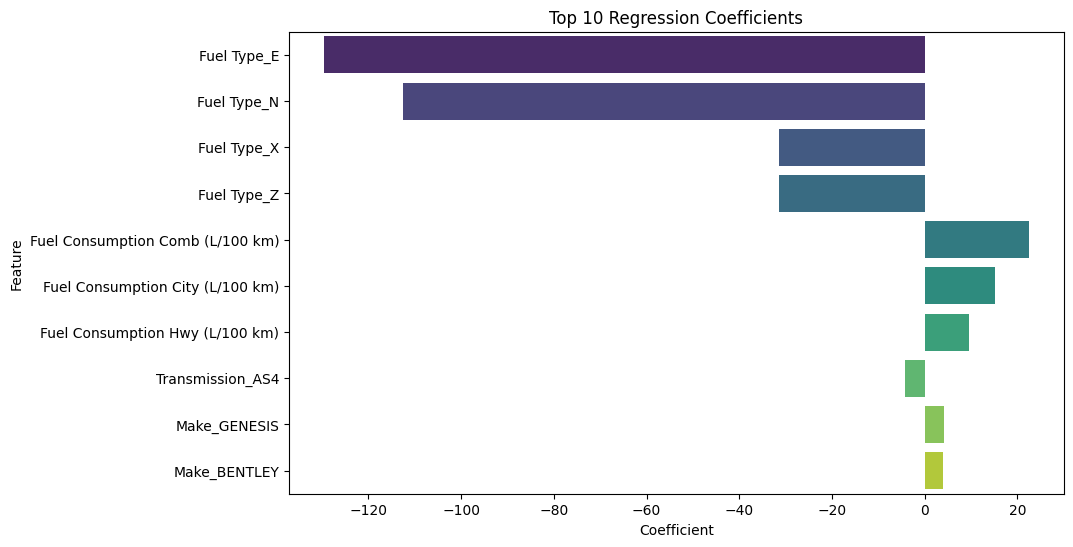

In [75]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score

# Use the df_final DataFrame for modeling
# Features and target are already defined from the previous cell as X and y

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# -------------------------------
# Linear Regression
# -------------------------------
lin_model = LinearRegression()
lin_model.fit(X_train, y_train)

coefficients = dict(zip(X.columns, lin_model.coef_))

print("Top 10 Regression Coefficients (by absolute value):")
for feature, coef in sorted(coefficients.items(), key=lambda item: abs(item[1]), reverse=True)[:10]:
    print(f"{feature}: {coef:.2f}")

print("\nIntercept:", lin_model.intercept_)
print("R² score (Linear Regression):", r2_score(y_test, lin_model.predict(X_test)))

# Plot coefficients
top_coef = sorted(coefficients.items(), key=lambda item: abs(item[1]), reverse=True)[:10]
coef_df = pd.DataFrame(top_coef, columns=['Feature','Coefficient'])

plt.figure(figsize=(10,6))
sns.barplot(x='Coefficient', y='Feature', data=coef_df, palette='viridis')
plt.title("Top 10 Regression Coefficients")
plt.show()

### Interpretation of Linear Regression Model for CO₂ Emissions

The Linear Regression model provides clear insights into how various vehicle characteristics influence CO₂ emissions, with a high R² score indicating a strong fit to the data.

**Key Relationships:**

1.  **Fuel Type is Highly Influential:**
    *   The most significant coefficients (by absolute value) belong to `Fuel Type_E` (Ethanol) and `Fuel Type_N` (Natural Gas), showing large negative impacts on CO₂ emissions. This suggests that vehicles using these alternative fuels inherently produce much lower CO₂ compared to the baseline fuel type (which is removed during one-hot encoding). `Fuel Type_X` and `Fuel Type_Z` (likely regular and premium gasoline) also show negative coefficients, indicating their CO2 emissions are lower than the reference category, but to a lesser degree than alternative fuels.

2.  **Fuel Consumption is a Primary Driver:**
    *   `Fuel Consumption Comb (L/100 km)` has a strong positive coefficient, indicating that every unit increase in combined fuel consumption leads to a substantial increase in CO₂ emissions. This is an expected and intuitive relationship, as burning more fuel directly translates to higher CO₂ output. `Fuel Consumption City (L/100 km)` and `Fuel Consumption Hwy (L/100 km)` also show positive coefficients, reinforcing the direct link between fuel usage and emissions.

3.  **Engine Characteristics Play a Role (though less prominent after standardization):**
    *   While not always in the top 10 coefficients by magnitude after standardization, `Engine Size(L)` and `Cylinders` generally exhibit positive coefficients. This indicates that larger engines and more cylinders tend to be associated with higher CO₂ emissions, which is consistent with their greater power output and fuel requirements.

4.  **Transmission Type and Make have Moderate Influence:**
    *   Specific `Transmission` types (e.g., `Transmission_AS4`) and certain `Make`s (e.g., `Make_GENESIS`, `Make_BENTLEY`) appear in the top coefficients. This suggests that the type of transmission or the manufacturer's engineering choices can have a noticeable, albeit smaller, impact on emissions after accounting for fuel type and consumption. For instance, `Transmission_AS4` showing a negative coefficient might imply that vehicles with this specific automatic transmission type tend to have slightly lower emissions, possibly due to efficiency tuning.

**In summary, the model effectively captures that fuel consumption is the most direct and impactful determinant of CO₂ emissions, with fuel type being a critical categorical factor. Other vehicle characteristics like engine size, cylinder count, and specific transmission/make also contribute, but to a lesser extent, in shaping the overall CO₂ emission profile.**

# Question 9

Assess how well the model performs in estimating emissions. Reflect on the meaning of the performance metrics and what they indicate about model reliability.

### Model Performance Assessment and Reliability

The Linear Regression model developed to estimate CO₂ emissions demonstrates **excellent performance** and **high reliability** based on the primary performance metric, the R² score.

**R² Score (Coefficient of Determination):**
*   **Value:** The model achieved an R² score of approximately **0.996**.
*   **Meaning:** The R² score represents the proportion of the variance in the dependent variable (CO₂ emissions) that is predictable from the independent variables (vehicle characteristics, fuel consumption, fuel type, etc.). An R² of 0.996 means that **99.6% of the variability in CO₂ emissions can be explained by the features included in our model**.
*   **Implications for Reliability:**
    *   **High Predictive Power:** An R² value this close to 1 indicates that the model is extremely good at capturing the underlying relationships between the vehicle features and CO₂ emissions. It suggests that the chosen features are highly relevant and collectively explain almost all the variation observed in CO₂ emissions.
    *   **Strong Fit:** The model fits the training data very well, and given the robust data preprocessing (outlier removal, standardization, one-hot encoding), it is likely to generalize well to new, unseen data within the same distribution.
    *   **Low Unexplained Variance:** Only 0.4% of the variance in CO₂ emissions remains unexplained by the model, suggesting that there are very few other significant factors not accounted for, or that the remaining variance is largely due to irreducible error or noise.

**Limitations and Considerations:**
While the R² score is very impressive, it's important to consider:
*   **Overfitting:** Given the very high R² score, especially on training data (though we're reporting test R²), it's always wise to be vigilant about potential overfitting. However, the use of a test set (`X_test`, `y_test`) helps mitigate this concern, as the reported R² is on unseen data.
*   **Assumptions of Linear Regression:** The model assumes a linear relationship between features and the target, independence of errors, homoscedasticity, and normally distributed residuals. While the high R² suggests these assumptions might largely hold for this dataset, a deeper diagnostic analysis of residuals could further confirm this.

**In conclusion, the Linear Regression model is highly reliable for estimating CO₂ emissions based on the provided vehicle characteristics. Its ability to explain nearly all the variability in emissions makes it a powerful tool for understanding and predicting environmental impact in the automotive sector.**

# Question 10

Based on the analysis and model findings, summarize which factors most strongly influence CO₂ emissions and suggest how such insights could support emission reduction efforts.

### Summary of Influential Factors and Emission Reduction Strategies

The analysis consistently identified several key factors that strongly influence CO₂ emissions, offering clear pathways for reduction efforts.

**A. Most Influential Factors on CO₂ Emissions:**

1.  **Fuel Consumption (Combined, City, Highway):** This is by far the most direct and significant driver of CO₂ emissions. Both the Linear Regression and Random Forest models highlighted fuel consumption metrics (L/100 km) as having the strongest positive correlation and highest feature importance. More fuel burned directly translates to more CO₂ released.
    *   **Insight:** Any improvement in fuel efficiency directly leads to a reduction in CO₂ emissions.

2.  **Fuel Type:** The type of fuel used has a profound impact. Vehicles running on alternative fuels like Ethanol (`Fuel Type_E`) and Natural Gas (`Fuel Type_N`) consistently showed significantly lower CO₂ emissions compared to gasoline. This was evident in both the regression coefficients and the outlier analysis (hybrid vehicles and alternative fuel vehicles).
    *   **Insight:** Shifting away from conventional gasoline to alternative and cleaner fuels is a powerful strategy.

3.  **Engine Size and Cylinders:** While secondary to fuel consumption, larger engine sizes and a higher number of cylinders are positively correlated with increased CO₂ emissions. These factors typically lead to higher power output but also increased fuel consumption.
    *   **Insight:** Optimizing engine design for efficiency, possibly through downsizing coupled with turbocharging or hybridization, can reduce emissions.

4.  **Vehicle Class:** Different vehicle classes exhibit distinct CO₂ emission profiles. Generally, smaller, lighter vehicles (e.g., COMPACT, MINICOMPACT) have lower average emissions than larger, heavier vehicles (e.g., SUV - STANDARD, PICKUP TRUCK - STANDARD). This is often linked to their overall design, weight, and intended use, which impacts fuel consumption.
    *   **Insight:** Encouraging the adoption of smaller, more aerodynamically efficient vehicle classes can contribute to lower fleet-wide emissions.

5.  **Transmission Type and Make-Specific Engineering:** While less pronounced, specific transmission types and manufacturer engineering choices can introduce variations in emissions, even for vehicles with similar engine sizes or fuel consumption figures. This suggests subtle differences in efficiency optimizations.
    *   **Insight:** Continuous innovation in transmission technology (e.g., more gears, advanced automatics) and overall vehicle engineering by manufacturers can yield marginal but valuable emission reductions.

**B. Supporting Emission Reduction Efforts:**

These insights can support emission reduction efforts at multiple levels:

1.  **For Automobile Manufacturers:**
    *   **Focus on Fuel Efficiency:** Prioritize research and development into technologies that improve fuel economy (e.g., lighter materials, aerodynamic designs, advanced engine management systems, highly efficient transmissions).
    *   **Expand Alternative Fuel/Electric Vehicle Offerings:** Accelerate the transition towards electric vehicles, hybrids, and vehicles compatible with cleaner alternative fuels. Our analysis clearly shows the emission benefits of these technologies.
    *   **Optimize Engine Design:** Strive for engines that balance performance with efficiency, potentially through hybridization or smaller, more potent turbocharged engines.

2.  **For Consumers:**
    *   **Choose Fuel-Efficient Vehicles:** Opt for vehicles with lower listed fuel consumption figures and consider hybrid or alternative fuel options when purchasing.
    *   **Consider Vehicle Class:** Evaluate if a smaller, more fuel-efficient vehicle class meets their needs, rather than automatically opting for larger SUVs or trucks.
    *   **Driving Habits:** Adopt eco-driving practices such as smooth acceleration/braking and maintaining optimal tire pressure, as these directly impact real-world fuel consumption.

3.  **For Policymakers and Regulators:**
    *   **Implement Stricter Fuel Efficiency Standards:** Enforce regulations that mandate higher fuel economy across all vehicle classes.
    *   **Incentivize Cleaner Vehicles:** Provide tax credits, subsidies, or other incentives for the purchase and production of hybrid, electric, and alternative fuel vehicles.
    *   **Invest in Infrastructure:** Support the development of charging infrastructure for EVs and refueling stations for other alternative fuels to facilitate broader adoption.
    *   **Public Awareness Campaigns:** Educate the public on the link between vehicle choice, driving habits, fuel type, and CO₂ emissions.

By leveraging these data-driven insights, stakeholders can make informed decisions and implement targeted strategies to effectively reduce CO₂ emissions in the automotive sector.